# Tutorial 3 — Contrastive learning: aligning galaxy images and star-formation histories

---
### The big picture: what is contrastive learning?

The first two tutorials took one route to multimodal learning: tokenize every
modality into discrete tokens and train a single any-to-any transformer to predict
the missing tokens. This tutorial takes a different, classic route:
**contrastive representation alignment** — the idea behind
[CLIP](https://arxiv.org/abs/2103.00020) and its sigmoid variant
[SigLIP](https://arxiv.org/abs/2303.15343).

The setup is simple. Each galaxy gives us two different "views" of the same object:

* a face-on stellar **image** `(8, 128, 128)` — what the galaxy looks like today, and
* its **star-formation history (SFH)** `(24,)` — how it built up its stars over
  cosmic time (log SFR vs. look-back time).

These two views are physically linked: a galaxy's present-day morphology and colour
are a direct consequence of *how and when it formed its stars*. Compact, red, smooth
galaxies tend to have old, long-quenched histories; extended, blue, structured
galaxies tend to be still forming stars. Contrastive learning is a way to teach a
model that link **without any labels** — using only the fact that a particular image
and a particular SFH belong to the same galaxy.

How? We build two separate **encoders** — one for images, one for SFHs — and ask each
to map its input to a vector on a shared **unit sphere** (a shared embedding space).
Then we train them with a single rule:

* the image and SFH of the **same** galaxy should land **close together** (high cosine
  similarity), and
* the image and SFH of **different** galaxies should be pushed **apart**.

That is the entire contrastive objective: *pull matched pairs together, push mismatched
pairs apart*. Concretely, for a batch of galaxies we score every (image, SFH) pair by a
dot product, treat the matched diagonal pairs as positives and all the off-diagonal
pairs as negatives, and minimize a loss that rewards high similarity on positives and
low similarity on negatives. (CLIP uses a softmax cross-entropy over the batch;
**SigLIP**, which we use here, replaces it with an independent sigmoid loss per pair,
which stays stable on the small batches we have.)

Once the two encoders are aligned, the shared space is useful in several ways:

* **Cross-modal retrieval** — embed a held-out galaxy's image and find the SFH whose
  embedding is closest (and vice-versa). If alignment worked, the true partner ranks
  near the top.
* **A frozen feature for downstream tasks** — the image embedding turns out to be a
  compact, physically-meaningful summary; a simple linear probe on top of it can predict
  the galaxy's full SFH from its image alone.

Unlike the generative transformer of Tutorial 2, contrastive learning does not
reconstruct anything — it learns a *metric* space where distance encodes physical
similarity. It is lightweight, label-free, and a natural complement to the token-based
multi-modal representation learnings.

![Contrastive alignment in a shared embedding space](assets/Image-Contrastive.png)

### What this notebook does
1. Load the z = 0 dataset and look at the image ↔ SFH correlation we hope to capture.
2. Build the CLIP model (two encoders + a SigLIP loss).
3. Train (or load) the model.
4. Evaluate it with **cross-modal retrieval metrics** (Recall@k, median rank).
5. Probe what the embedding learned with a **downstream** linear probe.

> **Two-pass workflow** (same as Tutorials 1–2). By default the notebook *loads* the
> trained checkpoint from `checkpoints/clip/` and evaluates. Set `GAL4M_TRAIN=1` to
> train the model inline instead (a few minutes on one GPU;
> `python -m sim.train_contrastive`).

> **Data & checkpoints.** This notebook pulls its data and pre-trained
> checkpoints from the Hugging Face Hub repo
> [`yueyingn/multimodal-galaxy-tutorial`](https://huggingface.co/yueyingn/multimodal-galaxy-tutorial) — each file downloads
> automatically on first use (into `data/` and `checkpoints/`). To fetch
> everything up front instead, run
> `from sim.hub import download_data, download_checkpoints; download_data(); download_checkpoints()`.

In [1]:
import os, json
import numpy as np
import torch
import matplotlib.pyplot as plt

from sim.contrastive import (
    CONFIGS, TrainConfig, load_clip_data, make_model, train_clip,
    encode_all, retrieval_metrics,
)
from sim.hub import DATA_DIR, CHECKPOINTS_DIR, data_path, checkpoint_path

TRAIN = os.environ.get("GAL4M_TRAIN", "0") == "1"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_DIR = os.path.join(CHECKPOINTS_DIR, "clip")      # checkpoints/clip/
NPZ = data_path("Snap99.npz")                         # local data/, else from the HF Hub

print("GAL4M_TRAIN =", TRAIN, "| device =", DEVICE)

# Light plotting style.
plt.rcParams.update({"font.family": "serif", "font.size": 13,
                     "axes.linewidth": 1.3, "figure.dpi": 110})

def load_img_norm():
    p = os.path.join(DATA_DIR, "img_norm.json")
    if os.path.exists(p):
        j = json.load(open(p));  return {"median": j["median"], "iqr": j["iqr"]}
    return {"median": 7.5859375, "iqr": 4.05078125}

IMG_NORM = load_img_norm()
print("Fixed image IQR norm:", IMG_NORM)

GAL4M_TRAIN = False | device = cpu
Fixed image IQR norm: {'median': 7.5859375, 'iqr': 4.05078125}


---
## 1. The data

The z = 0 file holds 3,878 TNG-100 galaxies. For contrastive alignment we only
need two of its modalities:

| Field | Shape | Meaning |
|-------|-------|---------|
| `star_faceon` | `(N, 8, 128, 128)` | 8-band face-on stellar image |
| `sfh` | `(N, 2, 24)` | star-formation history: channel 0 = look-back time grid (Gyr), channel 1 = log₁₀ SFR |

`load_clip_data` applies the **fixed** IQR image normalization (the same
`img_norm.json` constants used everywhere else in the tutorial — recomputing
per-load would silently rescale the images), regularizes the quenched SFH tail
(`log SFR < −3 → −3`), **standardizes** the SFH using train-set statistics (so the
Transformer sees a well-conditioned input), and makes a reproducible 90/10
train/val split.

In [2]:
DATA = load_clip_data(NPZ, IMG_NORM, standardize_sfh=True, val_frac=0.1, seed=0)

print(f"train: {DATA.img_train.shape[0]} galaxies   "
      f"val: {DATA.img_val.shape[0]} galaxies")
print(f"image tensor {tuple(DATA.img_train.shape)}   "
      f"SFH tensor {tuple(DATA.sfh_train.shape)}")
print(f"SFH train mean/std (used to standardize): "
      f"{DATA.sfh_mean:.3f} / {DATA.sfh_std:.3f}")

train: 3491 galaxies   val: 387 galaxies
image tensor (3491, 8, 128, 128)   SFH tensor (3491, 24)
SFH train mean/std (used to standardize): 0.140 / 0.849


### What correlation are we hoping to learn?

A few galaxies, each shown as its band-0 face-on image next to its SFH. Compact,
smooth (early-type) galaxies tend to have old, declining SFHs; extended,
structured (late-type) galaxies tend to be still forming stars. That image↔SFH
correlation is exactly the signal the contrastive loss exploits.

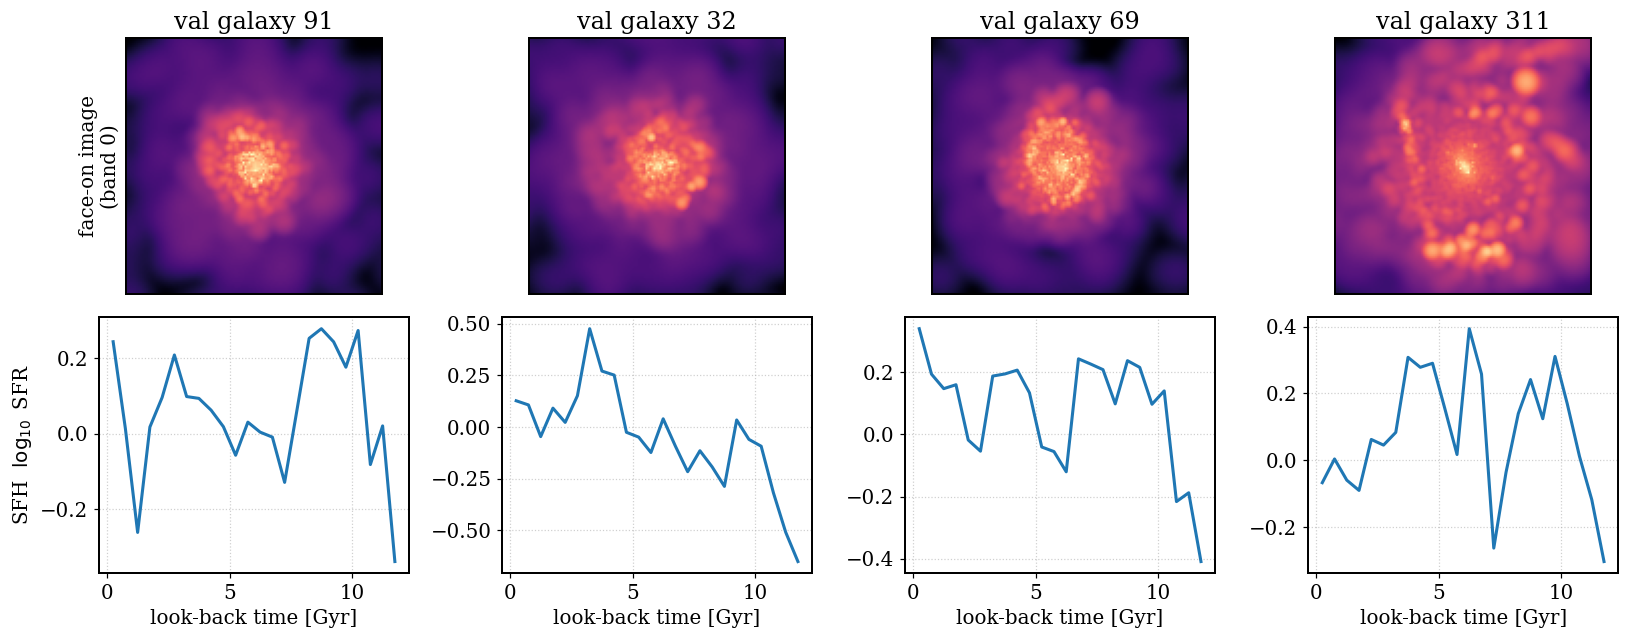

In [3]:
sfh_time = np.load(NPZ)["sfh"][0, 0, :]   # look-back time grid (same for all)
rng = np.random.default_rng(3)
show = rng.choice(len(DATA.img_val), 4, replace=False)

# DATA.sfh_* is standardized; convert back to physical log SFR for plotting.
sfh_val_phys = DATA.sfh_val.numpy() * DATA.sfh_std + DATA.sfh_mean

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for j, idx in enumerate(show):
    img = DATA.img_val[idx, 0].numpy()
    sfh = sfh_val_phys[idx]                     # physical log SFR
    axes[0, j].imshow(img, cmap="magma"); axes[0, j].set_xticks([]); axes[0, j].set_yticks([])
    axes[0, j].set_title(f"val galaxy {idx}")
    axes[1, j].plot(sfh_time, sfh, color="C0", lw=2)
    axes[1, j].set_xlabel("look-back time [Gyr]"); axes[1, j].grid(ls=":", alpha=0.6)
axes[0, 0].set_ylabel("face-on image\n(band 0)")
axes[1, 0].set_ylabel(r"SFH  $\log_{10}$ SFR")
plt.tight_layout(); plt.show()

## 2. The CLIP model

`GalaxySFHCLIP` wraps the two encoders and projects each onto a shared
`enc_dim`-D unit sphere:

* **Image encoder** — a `ConvMixer`: a patch-embedding stem + depthwise/pointwise
  residual blocks + global average pool. Cheap and surprisingly strong.
* **SFH encoder** — a small Transformer over the 24 time bins with learnable
  per-bin time embeddings and attention pooling to one vector.

**Loss — SigLIP (sigmoid).** For a batch, every image–SFH pair is scored by a dot
product, scaled by a learnable temperature and shifted by a learnable bias; the
diagonal pairs are labelled positive (+1) and all off-diagonal pairs negative
(−1) under a sigmoid/log-loss:

$$\mathcal{L} = -\frac{1}{B}\sum_{i,j}\log\sigma\!\big(z_{ij}\,(t\,\langle e^{\mathrm{img}}_i, e^{\mathrm{sfh}}_j\rangle + b)\big),\quad z_{ij}=+1\ \text{if } i=j\ \text{else } -1.$$

Unlike softmax InfoNCE it does not need a huge batch of in-batch negatives to be
stable (`sigmoid_loss`/`clip_loss` are both in `sim.contrastive`).

In [4]:
demo = make_model(CONFIGS["improved"])
n = sum(p.numel() for p in demo.parameters())
print(demo.image_encoder.__class__.__name__, "+", demo.sfh_encoder.__class__.__name__)
print(f"total parameters: {n/1e6:.2f}M")
# sanity check: a forward pass returns two L2-normalized embeddings
xi, xs = DATA.img_val[:4], DATA.sfh_val[:4]
ie, se = demo(xi, xs)
print("image emb", tuple(ie.shape), "  ||e||=", float(ie.norm(dim=-1).mean()))
print("SFH   emb", tuple(se.shape), "  ||e||=", float(se.norm(dim=-1).mean()))
del demo

/home/yueyingn/.conda/envs/myenv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


ConvMixer + SFHTransformerAttnEncoder
total parameters: 2.71M
image emb (4, 128)   ||e||= 1.0
SFH   emb (4, 128)   ||e||= 1.0


## 3. Train (or load) the model

The model trains in a few minutes on one GPU. Here we either run `train_clip`
inline (`GAL4M_TRAIN=1`) or load the delivered checkpoint. The training recipe is
tuned for the small (~3.6k-galaxy) dataset:

* **Orientation augmentation** — random 90° rotations + flips of the image. Face-on
  galaxies have no preferred in-plane orientation, so this is label-preserving for the
  SFH and is the single biggest anti-overfitting lever here.
* **Cosine learning rate with warm-up** — warm-up avoids the early large-LR
  instability of the SigLIP temperature; cosine decay lets it settle.
* **Model selection by validation Recall@1** — we keep the epoch that actually
  retrieves best, rather than the one with the lowest loss (the loss keeps drifting
  after retrieval has peaked).

In [5]:
def load_run(name="improved"):
    """Load (model, ckpt_meta) for the trained config from checkpoints/clip/."""
    path = checkpoint_path(f"clip/{name}/best.pt")
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    cfg = TrainConfig(**ckpt["config"])
    model = make_model(cfg).to(DEVICE)
    model.load_state_dict(ckpt["model_state"]); model.eval()
    return model, ckpt

if TRAIN:
    cfg = CONFIGS["improved"]
    print(f"=== training ({cfg.epochs} epochs) ===")
    model = make_model(cfg)
    hist, best_state, best_metrics = train_clip(model, DATA, cfg, DEVICE,
                                                verbose=True, log_every=20)
    model.load_state_dict(best_state); model.to(DEVICE).eval()
    ckpt = {"config": cfg.__dict__, "history": hist, "best_metrics": best_metrics,
            "sfh_mean": DATA.sfh_mean, "sfh_std": DATA.sfh_std}
else:
    model, ckpt = load_run("improved")
    bm = ckpt["best_metrics"]
    print(f"loaded model: best epoch {bm['epoch']}, "
          f"val Recall@1 {bm['val_recall@1']:.3f}")

loaded model: best epoch 194, val Recall@1 0.337


## 4. Evaluation — cross-modal retrieval

The honest test for an aligned space: given a held-out galaxy's **image**, rank
all val SFHs by cosine similarity — does its **true** SFH come out on top? (and
vice-versa). We report, on the 387 val galaxies:

* **Recall@k** — fraction of queries whose true match is in the top-k.
* **median rank** — typical rank of the true match (1 = perfect).

Random guessing on N = 387 gives Recall@1 ≈ 1/387 ≈ 0.003 and median rank ≈ 194.

In [6]:
ie, se = encode_all(model, DATA.img_val, DATA.sfh_val, DEVICE)
rm = retrieval_metrics(ie, se)

print(f"{'direction':11s} {'R@1':>6s} {'R@5':>6s} {'R@10':>6s} {'medRank':>8s}")
print("-" * 42)
for direction, label in [("i2s", "image→SFH"), ("s2i", "SFH→image")]:
    d = rm[direction]
    print(f"{label:11s} {d['recall@1']:6.3f} {d['recall@5']:6.3f} "
          f"{d['recall@10']:6.3f} {d['median_rank']:8.1f}")
print(f"\n(random guessing: R@1≈0.003, R@5≈0.013, R@10≈0.025, medRank≈199)")

direction      R@1    R@5   R@10  medRank
------------------------------------------
image→SFH    0.341  0.775  0.897      2.0
SFH→image    0.336  0.760  0.879      2.0

(random guessing: R@1≈0.003, R@5≈0.013, R@10≈0.025, medRank≈199)


## 5. Qualitative retrieval

**Image → SFH.** Take a val galaxy's image, find the val SFHs whose embedding is
most similar, and overlay them on the galaxy's *true* SFH. If alignment worked,
the retrieved SFHs (which the model has never been told belong together) bracket
the truth.

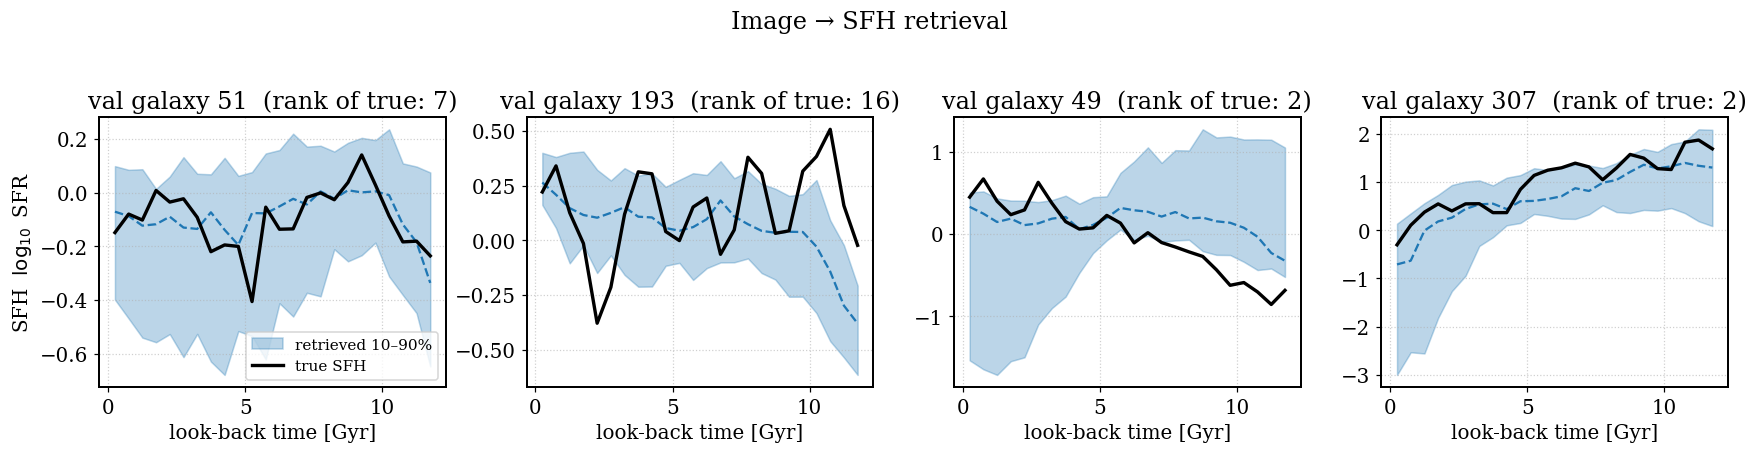

In [8]:
@torch.no_grad()
def embeddings():
    return encode_all(model, DATA.img_val, DATA.sfh_val, DEVICE)

def unstd(sfh):
    m = ckpt.get("sfh_mean", DATA.sfh_mean)
    s = ckpt.get("sfh_std",  DATA.sfh_std)
    return sfh * s + m

img_emb, sfh_emb = embeddings()
sfh_val_phys = unstd(DATA.sfh_val.numpy())   # back to physical log SFR

def retrieve_sfh_for_image(idx_src, topk=30):
    sims = (img_emb[idx_src:idx_src+1] @ sfh_emb.T).squeeze(0)
    order = torch.argsort(sims, descending=True)[:topk].numpy()
    return order

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
rng = np.random.default_rng(11)
for ax, idx in zip(axes, rng.choice(len(img_emb), 4, replace=False)):
    top = retrieve_sfh_for_image(idx, topk=30)
    ds = sfh_val_phys[top]
    ax.fill_between(sfh_time, np.percentile(ds, 10, 0), np.percentile(ds, 90, 0),
                    alpha=0.3, color="C0", label="retrieved 10–90%")
    ax.plot(sfh_time, np.median(ds, 0), color="C0", lw=1.5, ls="--")
    ax.plot(sfh_time, sfh_val_phys[idx], color="black", lw=2.2, label="true SFH")
    ax.set_title(f"val galaxy {idx}  (rank of true: "
                 f"{1 + int((( img_emb[idx]@sfh_emb.T) > (img_emb[idx]@sfh_emb[idx])).sum())})")
    ax.set_xlabel("look-back time [Gyr]"); ax.grid(ls=":", alpha=0.6)
axes[0].set_ylabel(r"SFH  $\log_{10}$ SFR"); axes[0].legend(fontsize=10)
plt.suptitle("Image → SFH retrieval", y=1.03)
plt.tight_layout(); plt.show()

**SFH → image.** The reverse: pick a val SFH and show the val images whose
embedding is closest. Galaxies with similar assembly histories should look
morphologically alike.

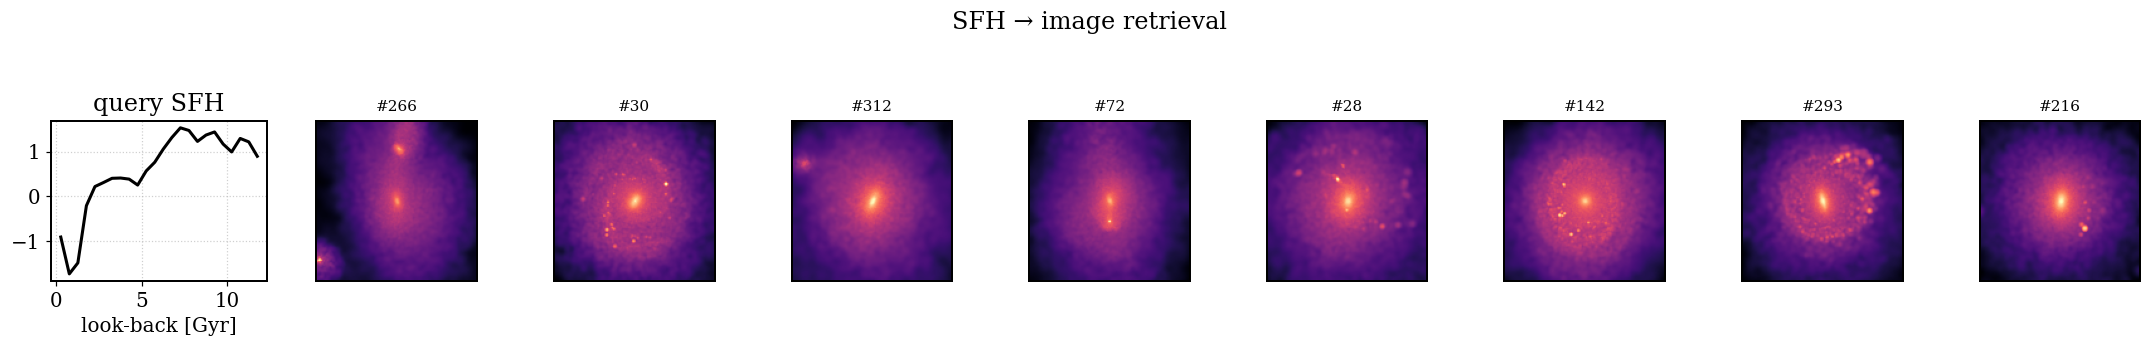

In [9]:
def retrieve_images_for_sfh(idx_src, topk=8):
    sims = (sfh_emb[idx_src:idx_src+1] @ img_emb.T).squeeze(0)
    return torch.argsort(sims, descending=True)[:topk].numpy()

idx_src = 30
top = retrieve_images_for_sfh(idx_src, topk=8)
fig, axes = plt.subplots(1, 9, figsize=(20, 3))
axes[0].plot(sfh_time, sfh_val_phys[idx_src], color="black", lw=2)
axes[0].set_title("query SFH"); axes[0].grid(ls=":", alpha=0.6)
axes[0].set_xlabel("look-back [Gyr]")
for ax, idx in zip(axes[1:], top):
    ax.imshow(DATA.img_val[idx, 0].numpy(), cmap="magma")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"#{idx}", fontsize=10)
plt.suptitle("SFH → image retrieval", y=1.05)
plt.tight_layout(); plt.show()

## 6. Downstream — is the frozen embedding physically meaningful?

Retrieval shows the spaces are *aligned*; a **linear probe** shows the embedding
is *informative*. We freeze the image encoder, take its 128-D embedding, and fit
a simple ridge regression (on the train split) to predict the **full 24-bin SFH**
of the galaxy from its image alone. We score R² on the val split against a
no-representation lower bound:

* **raw pixels** — ridge on a down-sampled image,
* **CLIP image embedding** — the frozen contrastive feature.

A higher R² means the contrastive image encoder packed more SFH-predictive
structure into its features. The embedding should clearly clear the raw-pixel bar.

In [10]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

def img_embeddings_split(which):
    imgs = getattr(DATA, f"img_{which}")
    with torch.no_grad():
        e = []
        for i in range(0, len(imgs), 256):
            e.append(model.image_embeddings_with_projection(
                imgs[i:i+256].to(DEVICE)).cpu())
    return torch.cat(e).numpy()

# Targets: physical (un-standardized) SFH.
def sfh_targets(which):
    return unstd(getattr(DATA, f"sfh_{which}").numpy())

def probe_r2(Xtr, ytr, Xte, yte, alpha=1.0):
    r = Ridge(alpha=alpha).fit(Xtr, ytr)
    return r2_score(yte, r.predict(Xte))

# Raw-pixel lower bound (band-0, 16x16 down-sample, flattened).
def raw_feats(which):
    imgs = getattr(DATA, f"img_{which}")[:, 0]            # (N,128,128)
    small = torch.nn.functional.avg_pool2d(imgs.unsqueeze(1), 8).flatten(1).numpy()
    return small

ytr = sfh_targets("train"); yte = sfh_targets("val")
results = {}
results["raw pixels"]     = probe_r2(raw_feats("train"), ytr, raw_feats("val"), yte, alpha=10.0)
results["CLIP embedding"] = probe_r2(img_embeddings_split("train"), ytr,
                                     img_embeddings_split("val"), yte, alpha=1.0)

print("Downstream: image features -> full 24-bin SFH   (val R^2, higher is better)")
print("-" * 48)
for k, v in results.items():
    print(f"  {k:16s}  R^2 = {v:.3f}")

Downstream: image features -> full 24-bin SFH   (val R^2, higher is better)
------------------------------------------------
  raw pixels        R^2 = 0.379
  CLIP embedding    R^2 = 0.600


### Predicted vs. true SFH from the image embedding

Using the image embedding → SFH ridge probe, a few held-out galaxies: the linear
readout of the frozen embedding already traces the true SFH shape, confirming the
contrastive features carry the assembly history.

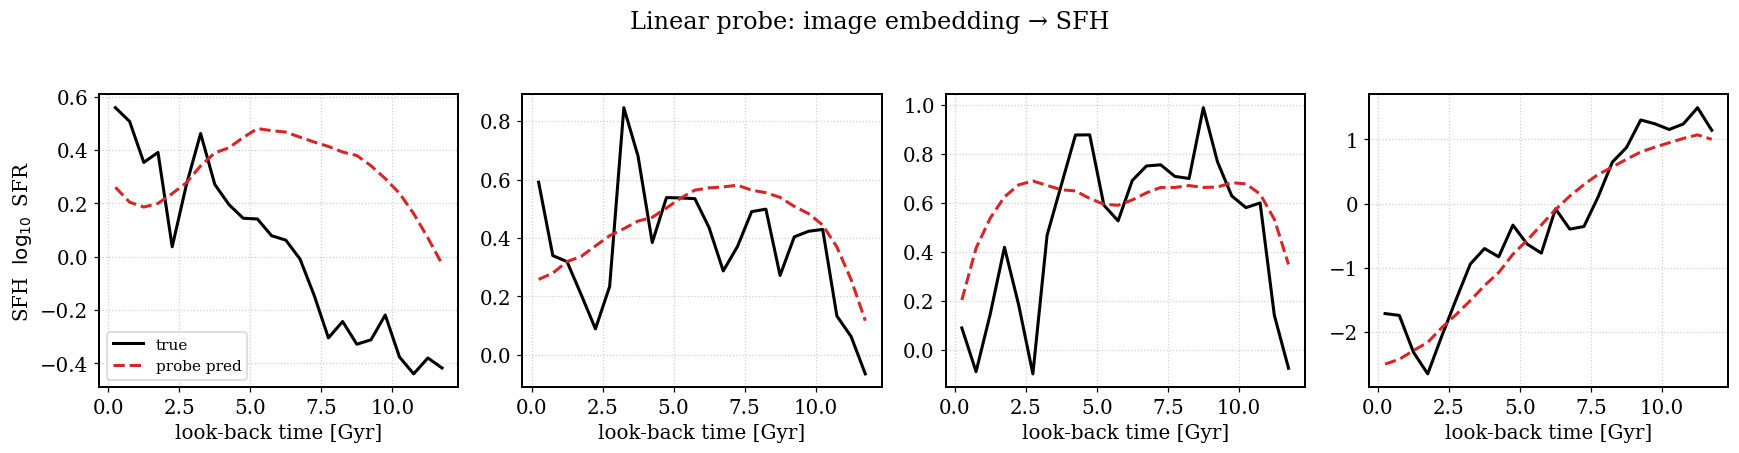

In [11]:
r = Ridge(alpha=1.0).fit(img_embeddings_split("train"), ytr)
pred = r.predict(img_embeddings_split("val"))
rng = np.random.default_rng(7)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, idx in zip(axes, rng.choice(len(yte), 4, replace=False)):
    ax.plot(sfh_time, yte[idx], color="black", lw=2, label="true")
    ax.plot(sfh_time, pred[idx], color="C3", lw=2, ls="--", label="probe pred")
    ax.set_xlabel("look-back time [Gyr]"); ax.grid(ls=":", alpha=0.6)
axes[0].set_ylabel(r"SFH  $\log_{10}$ SFR"); axes[0].legend(fontsize=10)
plt.suptitle("Linear probe: image embedding → SFH", y=1.03)
plt.tight_layout(); plt.show()

## 7. Summary

* A CLIP/SigLIP model aligns **z = 0 galaxy images** and **star-formation
  histories** into a shared space with **no labels** — only the pairing of each
  galaxy's two views.
* On 387 held-out galaxies, cross-modal **retrieval beats random by ~2 orders of
  magnitude** in median rank (a median rank of ~2 vs. ~194 for random guessing) —
  see the table and curves in §4.
* A frozen-embedding **linear probe** recovers the full 24-bin SFH from the image
  embedding with markedly higher R² than raw pixels, confirming the learned
  features are physically meaningful.

**Where this connects to the rest of the tutorial:** the FourM transformer in
Tutorial 2 also maps image → SFH, but generatively over discrete tokens. The
contrastive encoder here is a lightweight, label-free alternative that yields a
*metric* space useful for retrieval and as a downstream feature — a complementary
tool in the same Gal4M toolbox.

To retrain from scratch (a few minutes on one GPU):
```bash
python -m sim.train_contrastive     # trains the CLIP model -> checkpoints/clip/
```
or inline by setting `GAL4M_TRAIN=1` before running this notebook.